In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.datasets import load_iris
%matplotlib widget

In [2]:
# Cargar el conjunto de datos Iris
df = load_iris()


In [3]:
X = df.data[:, 0]  # usamos solo una variable (sepal length)
y = (df.target == 0).astype(int)  # Setosa = 1, No-setosa = 0

# Convertir a columna
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

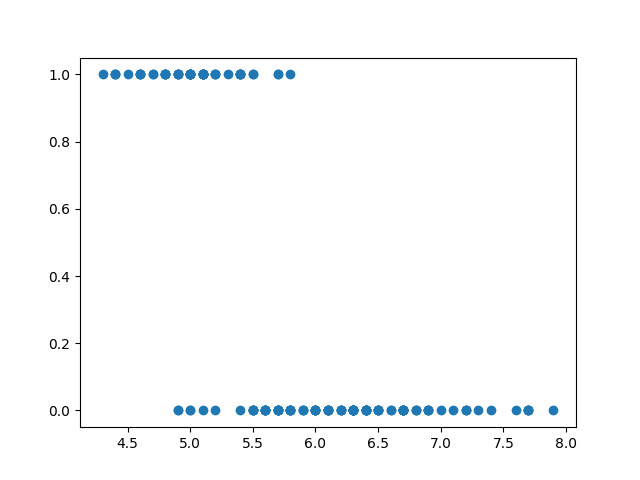

In [4]:
plt.close('all')
plt.scatter(X, y)
plt.show()

In [5]:
X_copy = X.copy()

In [6]:
## Z-score estandarización o normalización
m = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - m) / std

In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [8]:
m = len(y)
X_b = np.c_[np.ones((m, 1)), X]  # agregar bias

Theta:
 [[-1.98958009]
 [-3.58906851]]


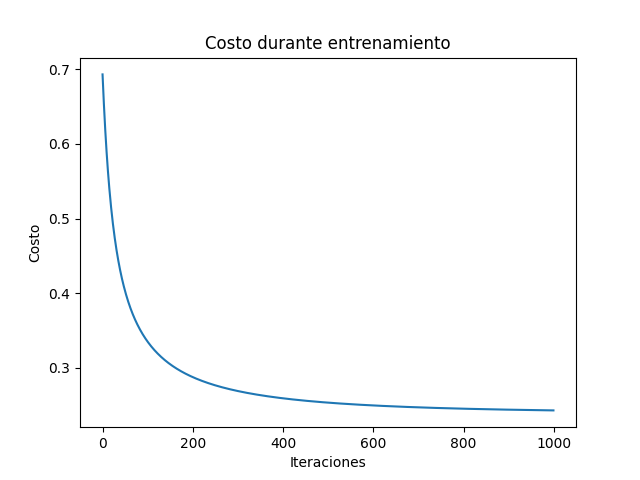

In [9]:
# Inicialización
theta = np.zeros((X_b.shape[1], 1))
lr = 1e-1
num_iter = 1000
cost_history = []

# Gradiente descendente
for i in range(num_iter):
    z = np.dot(X_b, theta)
    h = sigmoid(z)
    
    error = h - y
    grad = np.dot(X_b.T, error) / len(y)
    theta = theta - lr * grad
    
    # Evitar log(0)
    epsilon = 1e-5
    cost = -(1/len(y)) * np.sum(y*np.log(h+epsilon) + (1-y)*np.log(1-h+epsilon))
    cost_history.append(cost)

print("Theta:\n", theta)
# theta = np.array([[0], [5]])

# Gráfico de costo
plt.close()
plt.figure()
plt.plot(cost_history)
plt.title("Costo durante entrenamiento")
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.show()

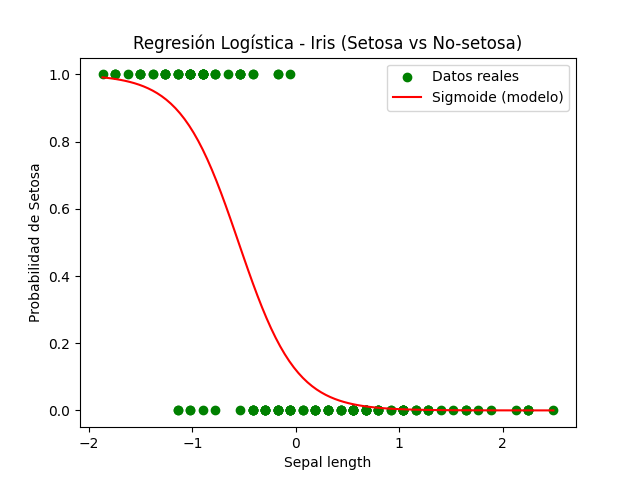

In [11]:
# Crear valores continuos para graficar curva
x_vals = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
x_vals_b = np.c_[np.ones((100,1)), x_vals]

# Predicción del modelo
y_prob = sigmoid(x_vals_b.dot(theta))

# Gráfica
plt.close('all')
plt.scatter(X, y, color='green', label='Datos reales')
plt.plot(x_vals, y_prob, color='red', label='Sigmoide (modelo)')
plt.xlabel('Sepal length')
plt.ylabel('Probabilidad de Setosa')
plt.legend()
plt.title('Regresión Logística - Iris (Setosa vs No-setosa)')
plt.show()